In [73]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr

# Import the custom package you generated
from hmc_dust.better_hmc import HMCSampler 
import matplotlib.pyplot as plt

num_overall_steps = 1000
burn_in = 200
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
inv_prior_cov_matrix = jnp.linalg.inv(prior_cov_matrix)
measurement_error_bar = 0.3

#inv_mass_matrix = jnp.linalg.inv(jnp.array([[1349.5989,  -512.74603],
#[-512.74603,  200.     ]]))
inv_mass_matrix = jnp.eye(2)
hess_x = 1.281865119934082
hess_y = 1.560537338256836

#inv_mass_matrix = jnp.array([[100.0, 0.0],
#                           [0.0, 1.0]])

def negative_logdensity(x):
    # e.g., Rosenbrock banana density function
    #return 100.0 * (x[1] - x[0]**2)**2 + (1.0 - x[0])**2 
    log_P_data_given_signal = 0.5*((jnp.sum(jnp.exp(x)) - 1)/measurement_error_bar)**2
    log_P_signal =  0.5*x.T @ inv_prior_cov_matrix @ x; 
    return log_P_data_given_signal + log_P_signal
    #return x[1]**2 + x[0]**2

# 2. Instantiate the wrapper with execution hyperparameters
sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=200,
    step_size=0.02,
    inv_mass_matrix = inv_mass_matrix,
    alpha=1.0,
    track_leapfrog_positions = True

)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(53440)
initial_coordinates = jnp.array([0.0, 0.0])

overall_position_arr, overall_momentum_arr, accept_prob_arr, overall_exact_position_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)



HMC sample 5/1000
HMC sample 10/1000
HMC sample 15/1000
HMC sample 20/1000
HMC sample 25/1000
HMC sample 30/1000
HMC sample 35/1000
HMC sample 40/1000
HMC sample 45/1000
HMC sample 50/1000
HMC sample 55/1000
HMC sample 60/1000
HMC sample 65/1000
HMC sample 70/1000
HMC sample 75/1000
HMC sample 80/1000
HMC sample 85/1000
HMC sample 90/1000
HMC sample 95/1000
HMC sample 100/1000
HMC sample 105/1000
HMC sample 110/1000
HMC sample 115/1000
HMC sample 120/1000
HMC sample 125/1000
HMC sample 130/1000
HMC sample 135/1000
HMC sample 140/1000
HMC sample 145/1000
HMC sample 150/1000
HMC sample 155/1000
HMC sample 160/1000
HMC sample 165/1000
HMC sample 170/1000
HMC sample 175/1000
HMC sample 180/1000
HMC sample 185/1000
HMC sample 190/1000
HMC sample 195/1000
HMC sample 200/1000
HMC sample 205/1000
HMC sample 210/1000
HMC sample 215/1000
HMC sample 220/1000
HMC sample 225/1000
HMC sample 230/1000
HMC sample 235/1000
HMC sample 240/1000
HMC sample 245/1000
HMC sample 250/1000
HMC sample 255/1000


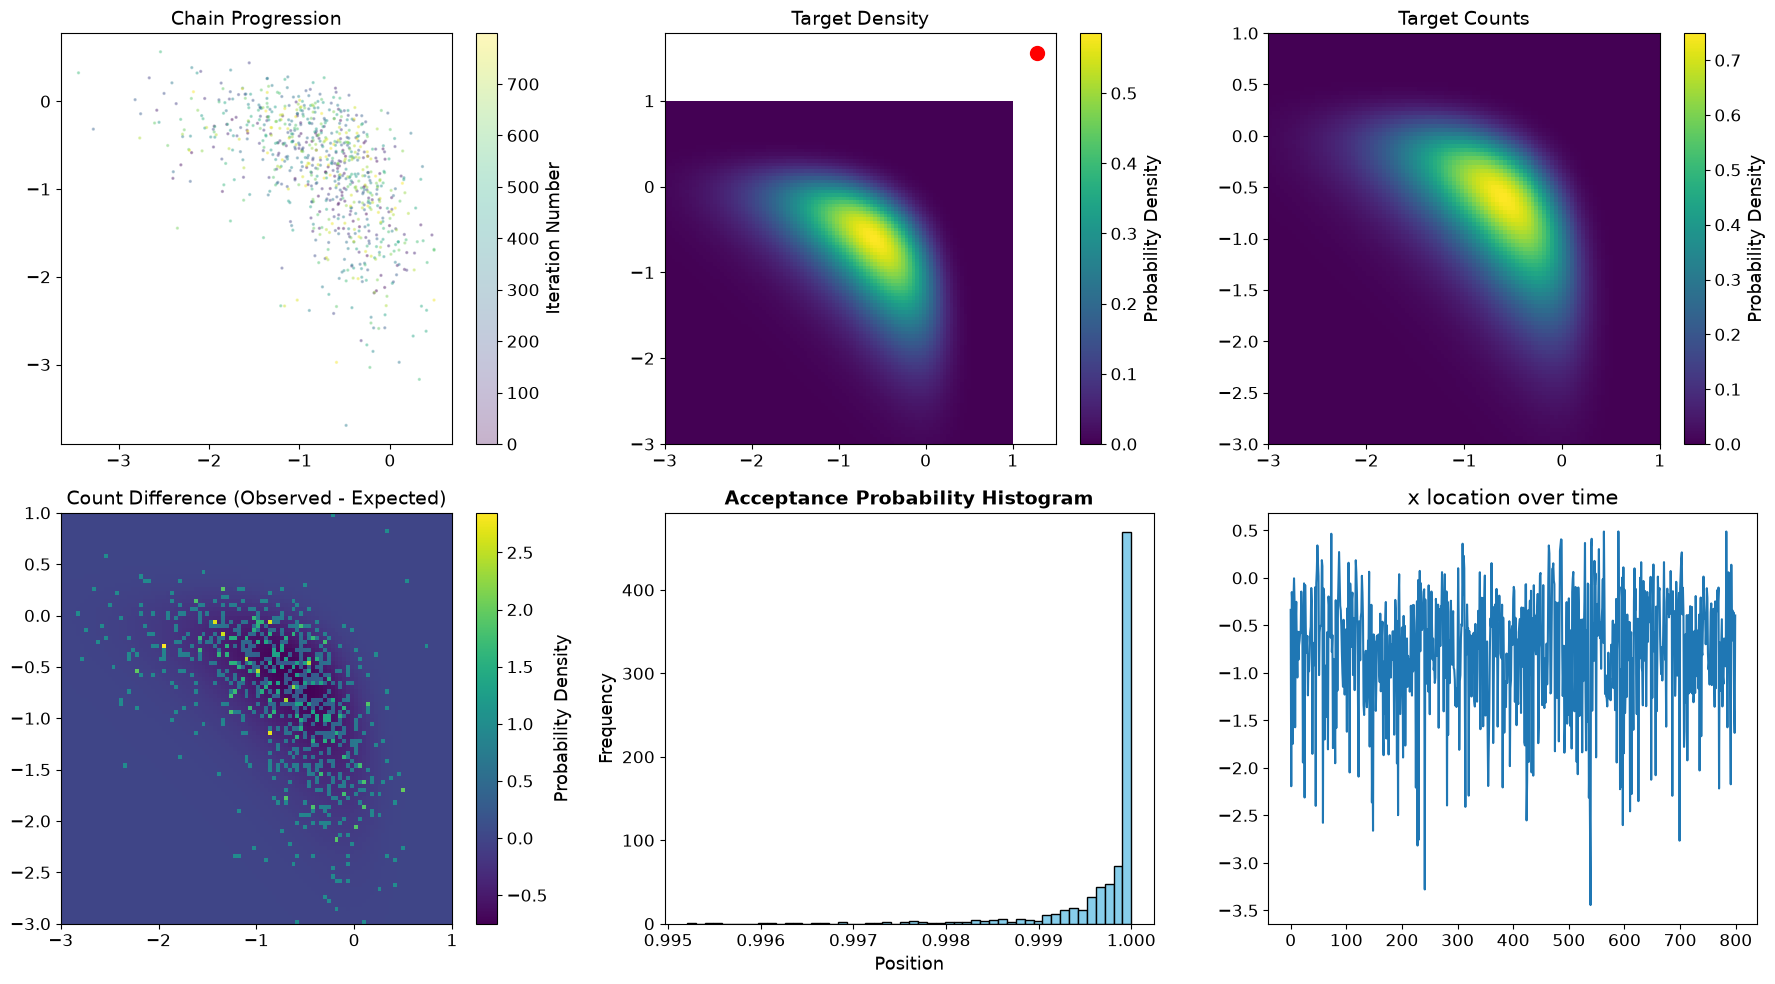

The covariance of the observed points is [[ 0.395498   -0.22596541]
 [-0.22596541  0.43675333]]
KL_divergence is 2.0804646015167236
The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density with jitter 0.00125 is 0.01421202439814806
The Hessian used to generate these samples was [[1. 0.]
 [0. 1.]]


In [74]:

num_good_samples = num_overall_steps - burn_in


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

x_min = -3
x_max = 1
y_min = -3
y_max = 1
n_cells = 100        # number of rectangles per axis
k = 10               # sub-samples per axis per cell (k*k samples per cell)

# cell *edges*, not centers — n_cells rectangles need n_cells+1 boundary points
x_edges = jnp.linspace(x_min, x_max, n_cells + 1)
y_edges = jnp.linspace(y_min, y_max, n_cells + 1)
dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]

# midpoint-rule offsets within a cell, in (0, 1)
offsets = (jnp.arange(k) + 0.5) / k

# fine grid coords: for every cell, k points spread across its interior
x_fine = (x_edges[:-1, None] + offsets[None, :] * dx).ravel()  # shape (n_cells*k,)
y_fine = (y_edges[:-1, None] + offsets[None, :] * dy).ravel()

Xf, Yf = jnp.meshgrid(x_fine, y_fine)
pos_fine = jnp.stack([Xf.ravel(), Yf.ravel()], axis=-1)

Z_fine = jax.vmap(negative_logdensity)(pos_fine)
Z_fine = jnp.exp(-Z_fine).reshape(Xf.shape)          # shape (n_cells*k, n_cells*k)

# block-average: group each k x k sub-block back into one cell and mean it
Z_avg = Z_fine.reshape(n_cells, k, n_cells, k).mean(axis=(1, 3))  # shape (n_cells, n_cells)


total_prob_density = jnp.sum(Z_avg)*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
normalized_density = Z_avg/total_prob_density
expected_bin_prob = normalized_density*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
expected_counts = expected_bin_prob*num_good_samples
observed_counts = jnp.zeros(Z_avg.shape)
x_values = jnp.floor((overall_position_arr[:, 0] - x_min) * n_cells / (x_max - x_min)).astype(int)
y_values = jnp.floor((overall_position_arr[:, 1] - y_min) * n_cells / (y_max - y_min)).astype(int)
observed_counts = observed_counts.at[y_values, x_values].add(1)
observed_bin_prob = observed_counts/num_good_samples

trial_space = jnp.arange(num_overall_steps)
iterations = np.arange(len(overall_position_arr))

scatter2 = axes[0][0].scatter(overall_position_arr[:, 0], overall_position_arr[:, 1], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[0][0].set_title("Chain Progression", fontsize=14)
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[0][0], label="Iteration Number") 

heatmap = axes[0][1].imshow(normalized_density, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[0][1].set_title("Target Density", fontsize = 14)
axes[0][1].scatter(hess_x, hess_y, color='red', s=100, zorder=5, label='Hessian Location')
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][1], label='Probability Density')

heatmap = axes[0][2].imshow(expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[0][2].set_title("Target Counts", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][2], label='Probability Density')

heatmap = axes[1][0].imshow(observed_counts - expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[1][0].set_title("Count Difference (Observed - Expected)", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[1][0], label='Probability Density')

axes[1][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[1][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Position')
axes[1][1].set_ylabel('Frequency')

axes[1][2].plot(iterations, overall_position_arr[:, 0])
axes[1][2].set_title("x location over time")

plt.tight_layout()
plt.show()

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)


chi_2_significance_mask = expected_counts >= 5

important_expected_counts = expected_counts[chi_2_significance_mask]
important_observed_counts = observed_counts[chi_2_significance_mask]
chi_2 = jnp.sum((important_observed_counts - important_expected_counts)**2/important_expected_counts)

cov = jnp.cov(overall_position_arr, rowvar=False)
print(f"The covariance of the observed points is {cov}")
print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1e-5)}")

linear_probs = normalized_density.ravel();
sampled_analytical_points = jnp.zeros(Z_avg.shape)
random_indices = jr.choice(rng, linear_probs.size, shape = (100000,), replace = True, p = linear_probs)
row_indices, col_indices = jnp.unravel_index(random_indices, normalized_density.shape)
sampled_analytical_points = sampled_analytical_points.at[row_indices, col_indices].add(1)
sampled_analytical_bin_prob = sampled_analytical_points/100000;
jitter = 1/num_good_samples
print(f"The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density with jitter {jitter} is {KL_divergence(expected_bin_prob, sampled_analytical_bin_prob, jitter = 1e-5)}")
print(f"The Hessian used to generate these samples was {inv_mass_matrix}")

In [75]:
# compute the average chi^2 using the measurement we took as a baseline
function_output_array = jnp.exp(overall_position_arr[:, 0]) + jnp.exp(overall_position_arr[:, 1])
chi_2_array = ((1 - function_output_array)/measurement_error_bar)**2
print(f"Average Chi^2 statistic based on the measurment: {jnp.average(chi_2_array)}")
# compute the average chi^2 using the prior as a baseline
# the i'th element of chi_2_prior_arr should come out to x^T(C^{-1})x, where x is the i'th row of overall_positon_arr and C is the prior cov matrix
chi_2_prior_array = jnp.sum(overall_position_arr * (overall_position_arr @ inv_prior_cov_matrix), axis=1)
print(f"Average Chi^2 statistic based on the prior: {jnp.average(chi_2_prior_array)}")

Average Chi^2 statistic based on the measurment: 0.9085908532142639
Average Chi^2 statistic based on the prior: 2.063791513442993


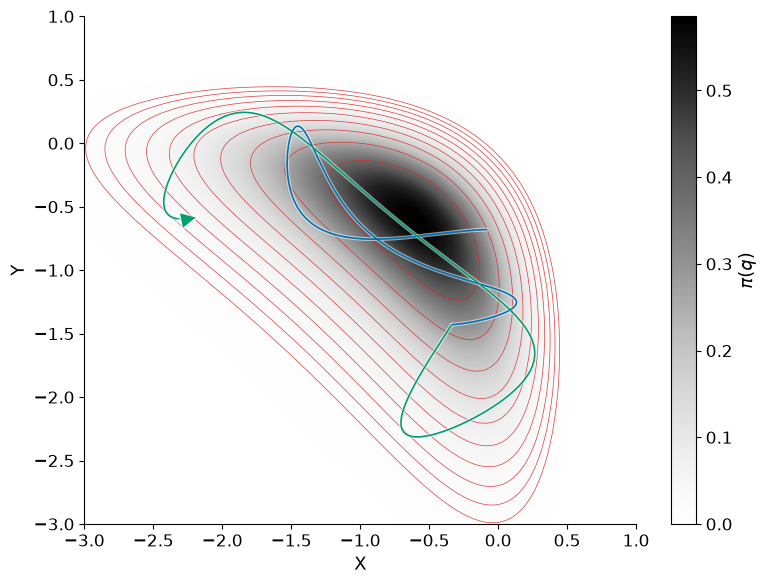

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import make_interp_spline

plt.rcParams.update({
    "pdf.fonttype": 42, "font.size": 12,
    "axes.labelsize": 13, "axes.titlesize": 15,
})

N, N_TRAJ = 200, 2
positions = overall_exact_position_arr.reshape(-1, overall_exact_position_arr.shape[-1])
positions = np.asarray(positions[: N * N_TRAJ], dtype=float)

TRAJ_COLORS = ["#0072B2", "#009E73", "#E69F00"]      # blue, bluish green, orange

def smooth(xy, factor=30):
    xy = np.asarray(xy, float)
    if len(xy) < 3:
        return xy
    d = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(xy, axis=0), axis=1))]
    keep = np.r_[True, np.diff(d) > 0]
    xy, d = xy[keep], d[keep]
    if len(xy) < 3 or d[-1] == 0:
        return xy
    spl = make_interp_spline(d / d[-1], xy, k=min(3, len(xy) - 1))
    return spl(np.linspace(0, 1, len(xy) * factor))

def tangent_offset(ax, curve, length_pt=13, n_back=10):
    """Shaft offset in POINTS, along the true local tangent at the curve end."""
    p1 = ax.transData.transform(curve[-1])
    p0 = ax.transData.transform(curve[max(0, len(curve) - 1 - n_back)])
    v = p1 - p0
    nrm = np.hypot(*v)
    if nrm == 0:
        return (0.0, 0.0)
    v /= nrm
    return (-v[0] * length_pt, -v[1] * length_pt)

# --- Build curves ONCE, with stitching ---------------------------------
n_traj = int(np.ceil(len(positions) / N))
curves = []
for k in range(n_traj):
    seg = positions[k * N:(k + 1) * N]
    if k > 0:
        prev_end = positions[k * N - 1]
        if not np.allclose(prev_end, seg[0]):
            seg = np.vstack([prev_end, seg])
    curves.append(smooth(seg))

# --- Figure -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(normalized_density, extent=[x_min, x_max, y_min, y_max],
                    origin="lower", cmap="Greys", aspect="auto",
                    interpolation="bilinear", zorder=0, rasterized=True)
fig.colorbar(heatmap, ax=ax, label=r"$\pi(q)$")

# --- Negative log-density contours: red, no halo ------------------------
ny, nx = normalized_density.shape
X, Y = np.meshgrid(np.linspace(x_min, x_max, nx),
                   np.linspace(y_min, y_max, ny))
dens = np.asarray(normalized_density, dtype=np.float64)
nll = -np.log(np.maximum(dens, 1e-300))
levels = nll.min() + np.arange(0.4, 4.01, 0.4)

ax.contour(X, Y, nll, levels=levels, colors="#D62728",
           linewidths=0.5, alpha=0.9, zorder=1)

# --- Trajectories: halos first, then colors ----------------------------
for s in curves:
    ax.plot(s[:, 0], s[:, 1], color="white", lw=2.8, alpha=0.55,
            solid_capstyle="round", solid_joinstyle="round", zorder=2)
for k, s in enumerate(curves):
    ax.plot(s[:, 0], s[:, 1], color=TRAJ_COLORS[k % len(TRAJ_COLORS)], lw=1.2,
            solid_capstyle="round", solid_joinstyle="round", zorder=3)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("X")
ax.set_ylabel("Y")
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)

fig.tight_layout()
fig.canvas.draw()          # transData must be current before we use it

# --- Single arrowhead, no tail -----------------------------------------
s = curves[-1]
ax.annotate("", xy=s[-1], xycoords="data",
            xytext=tangent_offset(ax, s, length_pt=13), textcoords="offset points",
            arrowprops=dict(arrowstyle="-|>",
                            color=TRAJ_COLORS[(n_traj - 1) % len(TRAJ_COLORS)],
                            lw=0, shrinkA=0, shrinkB=0, mutation_scale=26,
                            path_effects=[pe.Stroke(linewidth=2.8, foreground="white",
                                                    alpha=0.55), pe.Normal()]),
            zorder=4)

fig.savefig("hmc_trajectories.pdf", bbox_inches="tight", dpi=400)
plt.show()